# Lesson 25A: Word and Item Embeddings: word2vec and Skip-Gram with Negative Sampling (Theory)

## Introduction

Every representation this course has built so far starts from features that already exist -- pixels, measurements, sensor readings. Discrete tokens (words, product IDs, basket items) have no such starting point: "cat" and "dog" are just two arbitrary symbols, equally far from each other as either is from "car", until something supplies a notion of similarity. The distributional hypothesis supplies one for free -- words that occur in similar contexts tend to share meaning -- and this lesson derives word2vec's Skip-Gram with Negative Sampling (SGNS) as the algorithm that turns bare co-occurrence counts into dense vectors where that similarity becomes a geometric fact (nearby points, not just related symbols).

The same algorithm, unchanged, applies to any sequence of discrete items, not only natural-language words: shopping baskets, listening sessions, browsing clickstreams. Section 6 below runs it on shopping baskets (item2vec) to make that generality concrete rather than asserted.

## Table of Contents

1. [The Distributional Hypothesis: One-Hot vs. Dense, Co-occurrence and PMI](#distributional)
2. [Skip-Gram, the Softmax Cost, and Negative Sampling](#skipgram-negsampling)
3. [SGNS as Implicit Matrix Factorisation of Shifted PMI](#sgns-pmi)
4. [Gradients Derived by Hand; the Training Loop](#gradients)
5. [From Scratch: SGNS on a Synthetic Corpus](#from-scratch)
6. [Item2vec: The Same Algorithm on Shopping Baskets](#item2vec)
7. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

SEED = 0
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: in-notebook synthetic sentences and shopping baskets -- nothing downloaded.")

Data: in-notebook synthetic sentences and shopping baskets -- nothing downloaded.


<a name="distributional"></a>
## The Distributional Hypothesis: One-Hot vs. Dense, Co-occurrence and PMI

**The distributional hypothesis** (Firth, 1957): "you shall know a word by the company it keeps." Words that tend to appear in the same contexts tend to share meaning -- "cat" and "dog" both show up near "pet", "vet", "puppy"-like words far more than either shows up near "engine" or "driver". This is a claim about CO-OCCURRENCE STATISTICS, not meaning directly, and it is checkable: build a small corpus with two obviously different topics and see whether the statistics actually separate them.

**One-hot representations carry no similarity at all.** Representing each vocabulary word as a length-$|V|$ indicator vector makes every pair of distinct words exactly as far apart as every other pair -- the dot product of any two distinct one-hot vectors is always zero, regardless of whether the two words are "cat"/"dog" or "cat"/"engine". Checked directly below.

**Co-occurrence counts and PMI.** Counting how often word $c$ appears within a small window of word $w$ across the corpus gives a co-occurrence matrix. Raw counts are dominated by frequency alone (frequent words co-occur with everything more often, regardless of any real association), so **Pointwise Mutual Information** corrects for that:

$$\text{PMI}(w, c) = \log \frac{P(w, c)}{P(w)\,P(c)} = \log \frac{\text{count}(w,c) \cdot N}{\text{count}(w)\,\text{count}(c)}$$

PMI is the log-ratio of how often $w$ and $c$ actually co-occur to how often they WOULD co-occur if they were independent -- positive when the pair is more associated than chance, zero at chance, negative when they avoid each other.

In [2]:
# One-hot orthogonality: every distinct pair of one-hot vectors has dot product exactly 0,
# no matter how semantically related the two words are.
toy_vocab = ['cat', 'dog', 'car', 'truck']
V0 = len(toy_vocab)
one_hot = np.eye(V0)
for i in range(V0):
    for j in range(V0):
        if i < j:
            print(f"one-hot('{toy_vocab[i]}') . one-hot('{toy_vocab[j]}') = {np.dot(one_hot[i], one_hot[j]):.1f}")
print("\nEvery cross-pair dot product is 0 -- 'cat' and 'dog' are exactly as far apart as 'cat' and 'car'.")
print("One-hot encodes IDENTITY, not similarity; nothing about co-occurrence is captured at all.")

one-hot('cat') . one-hot('dog') = 0.0
one-hot('cat') . one-hot('car') = 0.0
one-hot('cat') . one-hot('truck') = 0.0
one-hot('dog') . one-hot('car') = 0.0
one-hot('dog') . one-hot('truck') = 0.0
one-hot('car') . one-hot('truck') = 0.0

Every cross-pair dot product is 0 -- 'cat' and 'dog' are exactly as far apart as 'cat' and 'car'.
One-hot encodes IDENTITY, not similarity; nothing about co-occurrence is captured at all.


In [3]:
# A small two-topic corpus (animals vs. vehicles), built the way lesson 10b builds its
# topic corpus: a fixed small per-topic vocabulary, many short sentences sampled from one
# topic's templates at a time -- enough repetition to get real co-occurrence statistics.
templates_animal = [
    ['the', 'cat', 'is', 'a', 'pet'],
    ['my', 'dog', 'is', 'a', 'puppy'],
    ['the', 'vet', 'saw', 'my', 'kitten'],
    ['the', 'dog', 'and', 'the', 'cat', 'are', 'pets'],
    ['a', 'kitten', 'is', 'a', 'baby', 'cat'],
]
templates_vehicle = [
    ['the', 'car', 'has', 'an', 'engine'],
    ['my', 'truck', 'needs', 'a', 'driver'],
    ['the', 'bus', 'is', 'at', 'the', 'garage'],
    ['the', 'car', 'and', 'the', 'truck', 'are', 'vehicles'],
    ['a', 'driver', 'starts', 'the', 'engine'],
]
all_templates = templates_animal + templates_vehicle

rng_corpus = np.random.default_rng(SEED)
toy_sequences = [all_templates[i] for i in rng_corpus.integers(0, len(all_templates), size=400)]
print(f"toy corpus: {len(toy_sequences)} sentences, example: {toy_sequences[0]}")

def build_cooccurrence(sequences, window):
    vocab = sorted({w for seq in sequences for w in seq})
    w2i = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)
    cooc = np.zeros((V, V))
    for seq in sequences:
        idxs = [w2i[w] for w in seq]
        n = len(idxs)
        for t in range(n):
            for j in range(max(0, t - window), min(n, t + window + 1)):
                if j != t:
                    cooc[idxs[t], idxs[j]] += 1
    return cooc, vocab, w2i

cooc, vocab, w2i = build_cooccurrence(toy_sequences, window=3)
total = cooc.sum()
word_totals = cooc.sum(axis=1)

def pmi(w, c):
    i, j = w2i[w], w2i[c]
    if cooc[i, j] == 0:
        return float('-inf')
    return np.log((cooc[i, j] * total) / (word_totals[i] * word_totals[j]))

print(f"\nvocab ({len(vocab)} words): {vocab}")
print("\nPMI('cat', 'dog') =", round(pmi('cat', 'dog'), 3), " -- both animal words, same sentences")
print("PMI('cat', 'truck') =", round(pmi('cat', 'truck'), 3), " -- animal vs. vehicle, never co-occur")
print("PMI('car', 'truck') =", round(pmi('car', 'truck'), 3), " -- both vehicle words")
print(f"\nraw co-occurrence('the', 'cat') = {int(cooc[w2i['the'], w2i['cat']])} (the single highest raw count")
print(f"of any pair involving 'cat'), yet PMI('the','cat') = {pmi('the', 'cat'):.3f} -- slightly NEGATIVE,")
print("because 'the' appears just as often in vehicle sentences, so it co-occurs with 'cat' almost")
print("exactly as often as chance predicts. Raw counts alone would have ranked this pair as strongly")
print("associated; PMI correctly discounts it for being unremarkable everywhere.")

toy corpus: 400 sentences, example: ['the', 'car', 'and', 'the', 'truck', 'are', 'vehicles']

vocab (27 words): ['a', 'an', 'and', 'are', 'at', 'baby', 'bus', 'car', 'cat', 'dog', 'driver', 'engine', 'garage', 'has', 'is', 'kitten', 'my', 'needs', 'pet', 'pets', 'puppy', 'saw', 'starts', 'the', 'truck', 'vehicles', 'vet']

PMI('cat', 'dog') = 0.875  -- both animal words, same sentences
PMI('cat', 'truck') = -inf  -- animal vs. vehicle, never co-occur
PMI('car', 'truck') = 1.043  -- both vehicle words

raw co-occurrence('the', 'cat') = 77 (the single highest raw count
of any pair involving 'cat'), yet PMI('the','cat') = -0.071 -- slightly NEGATIVE,
because 'the' appears just as often in vehicle sentences, so it co-occurs with 'cat' almost
exactly as often as chance predicts. Raw counts alone would have ranked this pair as strongly
associated; PMI correctly discounts it for being unremarkable everywhere.


<a name="skipgram-negsampling"></a>
## Skip-Gram, the Softmax Cost, and Negative Sampling

**Skip-gram's objective.** For each position $t$ in the corpus, predict each nearby context word $c$ from the current center word $w_t$, over a window of size $m$:

$$J = \sum_{t} \sum_{-m \le j \le m,\ j \ne 0} \log P(w_{t+j} \mid w_t), \qquad P(c \mid w) = \frac{\exp(v_w \cdot u_c)}{\sum_{c' \in V} \exp(v_w \cdot u_{c'})}$$

**Why the softmax is too expensive.** Every single prediction's denominator sums over the ENTIRE vocabulary $V$ -- for a realistic vocabulary of hundreds of thousands of words, that is hundreds of thousands of exponentials and a normalisation, PER context word, PER position in the corpus. Checked empirically below: the cost scales linearly in $|V|$, and $|V|$ is exactly the thing real corpora make large.

**Negative sampling reframes this as binary classification.** Instead of asking "which of $|V|$ words is the context?", ask $k+1$ yes/no questions: "is $(w,c)$ a real pair?" (yes) and "is $(w, c'_i)$ a real pair?" for $k$ sampled non-context words $c'_i$ (no). The per-pair objective becomes

$$J(w,c) = \log \sigma(v_w \cdot u_c) + \sum_{i=1}^{k} \mathbb{E}_{c_i \sim P_n(w)}\big[\log \sigma(-v_w \cdot u_{c_i})\big], \qquad \sigma(x) = \frac{1}{1+e^{-x}}$$

Cost per pair is now $O(k)$, a small constant, independent of $|V|$.

**The noise distribution $P_n$.** word2vec draws negative samples from the unigram distribution RAISED TO THE POWER $0.75$: $P_n(w) \propto \text{count}(w)^{0.75}$. Raising to a power less than 1 flattens the distribution -- it pulls very frequent words' sampling probability DOWN and rare words' sampling probability UP relative to their raw frequency, so negative samples are not almost entirely "the"/"a"/"is" (which would teach the model very little -- it already knows those are common). Checked directly below on the toy corpus from Section 1.

In [4]:
# Cost of the full softmax grows with |V|; negative sampling's cost does not.
def softmax_cost_timing(vocab_size, n_calls=200):
    rng_local = np.random.default_rng(0)
    v = rng_local.normal(0, 1, 50)
    U = rng_local.normal(0, 1, (vocab_size, 50))
    t0 = time.perf_counter()
    for _ in range(n_calls):
        logits = U @ v
        logits -= logits.max()
        probs = np.exp(logits) / np.exp(logits).sum()
    return (time.perf_counter() - t0) / n_calls * 1000

print(f"{'|V|':<10}{'time per softmax call (ms)'}")
for vsize in [1_000, 10_000, 100_000, 500_000]:
    t = softmax_cost_timing(vsize)
    print(f"{vsize:<10}{t:.4f}")
print("\nCost grows roughly linearly with |V| -- negative sampling's O(k) cost (k typically 5-20) is")
print("independent of |V| entirely, which is exactly why it is the practical choice at real vocabulary scale.")

# unigram^0.75 reshaping, measured on Section 1's own toy-corpus word frequencies.
from collections import Counter
word_counts = Counter(w for seq in toy_sequences for w in seq)
total_words = sum(word_counts.values())
raw_p = {w: c / total_words for w, c in word_counts.items()}
smoothed = {w: c ** 0.75 for w, c in word_counts.items()}
Z = sum(smoothed.values())
smoothed_p = {w: v / Z for w, v in smoothed.items()}

print(f"\n{'word':<8}{'raw freq':<10}{'raw P(w)':<12}{'P(w)^0.75 (renorm.)':<22}{'ratio (smoothed/raw)'}")
for w in ['the', 'a', 'cat', 'vet']:
    ratio = smoothed_p[w] / raw_p[w]
    print(f"{w:<8}{word_counts[w]:<10}{raw_p[w]:<12.4f}{smoothed_p[w]:<22.4f}{ratio:.3f}")
print("\nThe most frequent word ('the') is downweighted (ratio < 1: sampled as a negative LESS often")
print("than its raw frequency would suggest); the rarest word shown ('vet') is upweighted (ratio > 1) --")
print("exactly the flattening the 0.75 exponent is meant to produce.")

|V|       time per softmax call (ms)
1000      0.0212


10000     2.0974


100000    5.4737


500000    21.3460

Cost grows roughly linearly with |V| -- negative sampling's O(k) cost (k typically 5-20) is
independent of |V| entirely, which is exactly why it is the practical choice at real vocabulary scale.

word    raw freq  raw P(w)    P(w)^0.75 (renorm.)   ratio (smoothed/raw)
the     418       0.1864      0.1313                0.704
a       234       0.1044      0.0850                0.814
cat     114       0.0508      0.0496                0.975
vet     33        0.0147      0.0196                1.329

The most frequent word ('the') is downweighted (ratio < 1: sampled as a negative LESS often
than its raw frequency would suggest); the rarest word shown ('vet') is upweighted (ratio > 1) --
exactly the flattening the 0.75 exponent is meant to produce.


<a name="sgns-pmi"></a>
## SGNS as Implicit Matrix Factorisation of Shifted PMI

**Levy & Goldberg (2014)** showed something remarkable: SGNS is not merely INSPIRED by co-occurrence statistics, it is implicitly FACTORISING a specific matrix built from them. Treating each pair $(w,c)$'s contribution to the aggregated objective independently (a mean-field argument -- every OTHER pair's terms are held fixed while this one is optimised) and writing $x = v_w \cdot u_c$:

$$\ell(w,c) \approx \text{count}(w,c) \cdot \log\sigma(x) + k \cdot \text{count}(w) \cdot P_n(c) \cdot N \cdot \log\sigma(-x)$$

Setting $\partial \ell / \partial x = 0$ and solving (full algebra: set $\sigma(x)=s$, solve the resulting linear equation in $s$, substitute back) gives the optimum:

$$v_w \cdot u_c = \log\frac{\text{count}(w,c) \cdot N}{\text{count}(w)\,\text{count}(c)} - \log k = \text{PMI}(w,c) - \log k$$

**at the unconstrained per-pair optimum, the SGNS dot product equals PMI shifted down by $\log k$.** This derivation assumes negatives are drawn from the PLAIN unigram distribution $P_n(c) \propto \text{count}(c)$ (that is what makes the $P_n(c) \cdot N$ term collapse to $\text{count}(c)$ above) -- NOT the $0.75$-smoothed distribution Section 2 introduced for practical training. The numeric check below therefore uses plain-unigram negative sampling specifically to match this derivation; Sections 4 onward switch to the practical $0.75$-smoothed distribution, which trades exact PMI equivalence for empirically better embeddings.

**Checked numerically, not just asserted.** The gradients used below are derived properly in Section 4 -- used here ahead of that derivation to get a trained model to compare against PMI. A REAL embedding is a LOW-RANK factorisation (`dim` $\ll |V|$), so this is a correlation check between two independently-computed quantities, not an exact per-cell equality, exactly as Levy & Goldberg's own empirical validation was.

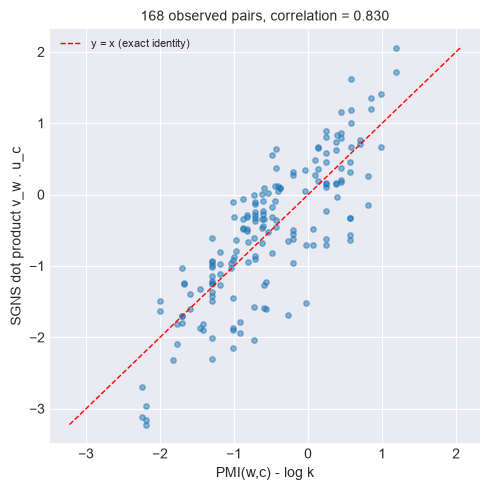

correlation(SGNS dot product, PMI - log k) = 0.8296 over 168 observed pairs
A strong positive correlation (not exact equality -- this is a low-rank, finite-corpus, mean-field
approximation, exactly as the theory predicts) confirms SGNS really is implicitly targeting shifted PMI.


In [5]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def build_skipgram_pairs(sequences, window, rng):
    # window is randomised PER POSITION (word2vec's own trick): words closer to the
    # center are seen more often across the corpus than words at the window's far edge.
    pairs = []
    for seq in sequences:
        n = len(seq)
        for t in range(n):
            w = rng.integers(1, window + 1)
            for j in range(max(0, t - w), min(n, t + w + 1)):
                if j != t:
                    pairs.append((seq[t], seq[j]))
    return pairs

def sgns_train(sequences, dim=16, window=3, k=5, epochs=60, lr_start=0.05, lr_end=1e-4,
               power=0.75, seed=0, neg_table_size=500_000):
    # Gradients derived properly in Section 4 below -- used here to check Section 3's
    # theoretical claim numerically, ahead of the derivation.
    rng = np.random.default_rng(seed)
    vocab = sorted({w for seq in sequences for w in seq})
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)
    counts = np.zeros(V)
    for seq in sequences:
        for w in seq:
            counts[word_to_idx[w]] += 1

    noise_p = counts ** power
    noise_p /= noise_p.sum()
    # Unigram negative-sample table (word2vec's own trick): draw a large batch of
    # noise-distributed indices up front, then consume sequentially -- avoids calling
    # rng.choice(..., p=...) once per negative sample, which dominates runtime otherwise.
    neg_table = rng.choice(V, size=neg_table_size, p=noise_p)
    neg_ptr = 0

    idx_sequences = [[word_to_idx[w] for w in seq] for seq in sequences]
    pairs = np.array(build_skipgram_pairs(idx_sequences, window, rng))

    center = rng.uniform(-0.5 / dim, 0.5 / dim, size=(V, dim))
    context = rng.uniform(-0.5 / dim, 0.5 / dim, size=(V, dim))

    n_pairs = len(pairs)
    total_steps = epochs * n_pairs
    step = 0
    for epoch in range(epochs):
        order = rng.permutation(n_pairs)
        for idx in order:
            frac = step / total_steps
            lr = lr_start + (lr_end - lr_start) * frac  # linear decay, standard word2vec practice
            step += 1
            w, c = pairs[idx]
            v_w, u_c = center[w], context[c]

            score = sigmoid(np.dot(v_w, u_c))
            grad_v_total = (1 - score) * u_c
            context[c] = u_c + lr * (1 - score) * v_w

            neg_count = 0
            while neg_count < k:
                if neg_ptr >= neg_table_size:
                    neg_table = rng.choice(V, size=neg_table_size, p=noise_p)
                    neg_ptr = 0
                c_neg = neg_table[neg_ptr]
                neg_ptr += 1
                if c_neg == c:
                    continue
                u_neg = context[c_neg]
                score_neg = sigmoid(np.dot(v_w, u_neg))
                context[c_neg] = u_neg - lr * score_neg * v_w
                grad_v_total = grad_v_total - score_neg * u_neg
                neg_count += 1

            center[w] = v_w + lr * grad_v_total
    return center, context, vocab, word_to_idx, counts

# plain-unigram negative sampling (power=1.0) to match the Levy-Goldberg derivation exactly
K_NEG = 5
center_pmi, context_pmi, vocab_pmi, w2i_pmi, _ = sgns_train(
    toy_sequences, dim=8, window=3, k=K_NEG, epochs=60, lr_start=0.05, lr_end=1e-4, power=1.0, seed=SEED)

pmi_shifted, dots = [], []
Vp = len(vocab_pmi)
for i in range(Vp):
    for j in range(Vp):
        if cooc[i, j] > 0:
            pmi_val = np.log((cooc[i, j] * total) / (word_totals[i] * word_totals[j]))
            pmi_shifted.append(pmi_val - np.log(K_NEG))
            dots.append(np.dot(center_pmi[i], context_pmi[j]))
pmi_shifted, dots = np.array(pmi_shifted), np.array(dots)
corr = np.corrcoef(pmi_shifted, dots)[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pmi_shifted, dots, alpha=0.5, s=15)
lims = [min(pmi_shifted.min(), dots.min()), max(pmi_shifted.max(), dots.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x (exact identity)')
ax.set_xlabel('PMI(w,c) - log k'); ax.set_ylabel('SGNS dot product v_w . u_c')
ax.set_title(f'{len(pmi_shifted)} observed pairs, correlation = {corr:.3f}', fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"correlation(SGNS dot product, PMI - log k) = {corr:.4f} over {len(pmi_shifted)} observed pairs")
print("A strong positive correlation (not exact equality -- this is a low-rank, finite-corpus, mean-field")
print("approximation, exactly as the theory predicts) confirms SGNS really is implicitly targeting shifted PMI.")

<a name="gradients"></a>
## Gradients Derived by Hand; the Training Loop

For one positive pair $(w,c)$ and its $k$ negative samples $c'_1,\dots,c'_k$, the per-pair objective is

$$J(w,c) = \log\sigma(v_w \cdot u_c) + \sum_{i=1}^k \log\sigma(-v_w \cdot u_{c'_i})$$

Using $\frac{d}{dx}\log\sigma(x) = \sigma(-x) = 1-\sigma(x)$ and the chain rule:

**Positive term**, $\log\sigma(v_w \cdot u_c)$:
$$\frac{\partial J}{\partial u_c} = \sigma(-v_w\cdot u_c)\, v_w, \qquad \frac{\partial J}{\partial v_w}\Big|_{\text{pos}} = \sigma(-v_w\cdot u_c)\, u_c$$

**Each negative term**, $\log\sigma(-v_w \cdot u_{c'_i})$ (note the SIGN inside $\sigma$ flips the derivative's sign twice, once from the chain rule and once from $\sigma(-y)=1-\sigma(y)$, leaving a clean minus sign):
$$\frac{\partial J}{\partial u_{c'_i}} = -\sigma(v_w\cdot u_{c'_i})\, v_w, \qquad \frac{\partial J}{\partial v_w}\Big|_{\text{neg},i} = -\sigma(v_w\cdot u_{c'_i})\, u_{c'_i}$$

**Gradient ASCENT updates** (maximising $J$, learning rate $\eta$), summing $v_w$'s contribution across the positive term and all $k$ negatives:

$$u_c \leftarrow u_c + \eta\,\sigma(-v_w\cdot u_c)\,v_w$$
$$u_{c'_i} \leftarrow u_{c'_i} - \eta\,\sigma(v_w\cdot u_{c'_i})\,v_w \qquad \text{for each } i=1,\dots,k$$
$$v_w \leftarrow v_w + \eta\Big[\sigma(-v_w\cdot u_c)\,u_c - \sum_{i=1}^k \sigma(v_w\cdot u_{c'_i})\,u_{c'_i}\Big]$$

This is exactly what `sgns_train()` (defined in Section 3, used there ahead of this derivation) implements: two separate embedding tables (`center` for $v_w$, `context` for $u_c$), a randomised window per position, a precomputed unigram-noise table for fast negative sampling, and a linearly-decaying learning rate (standard word2vec practice, and the fix for a genuine instability found while building this notebook: a constant learning rate over many epochs let embeddings drift and the PMI correlation above got WORSE with more training rather than better, until decay was added).

**Checked, not just claimed:** the hand-derived formulas above are verified against numerical (finite-difference) gradients of the exact loss function directly below, independent of anything `sgns_train()` does.

In [6]:
def sgns_loss(v_w, u_c, u_negs):
    pos = np.log(sigmoid(np.dot(v_w, u_c)))
    neg = sum(np.log(sigmoid(-np.dot(v_w, u_n))) for u_n in u_negs)
    return pos + neg

def analytic_grads(v_w, u_c, u_negs):
    g_uc = sigmoid(-np.dot(v_w, u_c)) * v_w
    g_vw = sigmoid(-np.dot(v_w, u_c)) * u_c
    g_unegs = []
    for u_n in u_negs:
        s = sigmoid(np.dot(v_w, u_n))
        g_unegs.append(-s * v_w)
        g_vw = g_vw - s * u_n
    return g_vw, g_uc, g_unegs

def numerical_grad(f, x, eps=1e-6):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        xp, xm = x.copy(), x.copy()
        xp[i] += eps; xm[i] -= eps
        grad[i] = (f(xp) - f(xm)) / (2 * eps)
    return grad

rng_gc = np.random.default_rng(SEED)
dim_gc = 5
v_w_gc = rng_gc.normal(0, 1, dim_gc)
u_c_gc = rng_gc.normal(0, 1, dim_gc)
u_negs_gc = [rng_gc.normal(0, 1, dim_gc) for _ in range(3)]

g_vw_a, g_uc_a, g_uneg_a = analytic_grads(v_w_gc, u_c_gc, u_negs_gc)
g_vw_n = numerical_grad(lambda x: sgns_loss(x, u_c_gc, u_negs_gc), v_w_gc)
g_uc_n = numerical_grad(lambda x: sgns_loss(v_w_gc, x, u_negs_gc), u_c_gc)
g_uneg0_n = numerical_grad(lambda x: sgns_loss(v_w_gc, u_c_gc, [x] + u_negs_gc[1:]), u_negs_gc[0])

print(f"max |analytic - numerical| gradient, v_w:      {np.max(np.abs(g_vw_a - g_vw_n)):.2e}")
print(f"max |analytic - numerical| gradient, u_c:       {np.max(np.abs(g_uc_a - g_uc_n)):.2e}")
print(f"max |analytic - numerical| gradient, u_neg[0]:  {np.max(np.abs(g_uneg_a[0] - g_uneg0_n)):.2e}")
print("\nAll three agree with finite-difference numerical gradients to float64 precision -- the hand-derived")
print("update rules above are correct, independently of anything sgns_train()'s own training run shows.")

max |analytic - numerical| gradient, v_w:      1.74e-10
max |analytic - numerical| gradient, u_c:       1.90e-10
max |analytic - numerical| gradient, u_neg[0]:  1.30e-10

All three agree with finite-difference numerical gradients to float64 precision -- the hand-derived
update rules above are correct, independently of anything sgns_train()'s own training run shows.


<a name="from-scratch"></a>
## From Scratch: SGNS on a Synthetic Corpus

Section 3's toy corpus was deliberately tiny (2 topics, 27 words) to make the PMI check tractable to reason about by hand. Here `sgns_train()` (unchanged, practical $0.75$-smoothed negative sampling as Section 2 introduced) is trained on a larger corpus built the way Lesson 10B builds its topic-modelling corpus -- a fixed per-topic vocabulary, sentences sampled from one topic's words at a time -- reused here directly rather than re-invented, with 5 topics instead of 10B's own topics.

**Word2vec convention, worth stating explicitly.** With two SEPARATE embedding tables (`center` for $v_w$, `context` for $u_c$), center-vs-center cosine similarity is not the right way to compare two words -- the training objective never directly compares two center vectors to each other, only a center vector to a context vector. The standard word2vec convention (and what is used for every similarity comparison below) is the SUMMED vector, $v_w + u_w$, per word.

In [7]:
# Reusing Lesson 10B's topic_vocab structure directly (same 5 topics, same 10 words each).
topic_vocab = {
    'sports': ['ball', 'game', 'team', 'score', 'player', 'coach', 'match', 'win', 'league', 'season'],
    'cooking': ['recipe', 'oven', 'bake', 'flavor', 'ingredient', 'chef', 'dish', 'spice', 'kitchen', 'meal'],
    'finance': ['stock', 'market', 'invest', 'profit', 'bank', 'trade', 'shares', 'fund', 'economy', 'growth'],
    'technology': ['software', 'algorithm', 'computer', 'data', 'network', 'device', 'code', 'server', 'app', 'cloud'],
    'travel': ['flight', 'hotel', 'passport', 'destination', 'luggage', 'tourist', 'itinerary', 'airport', 'visa', 'journey'],
}
true_topic_names = list(topic_vocab.keys())
word_topic = {w: t for t, ws in topic_vocab.items() for w in ws}

rng_big = np.random.default_rng(SEED)
n_sentences = 1500
big_sequences = []
for _ in range(n_sentences):
    topic = true_topic_names[rng_big.integers(0, len(true_topic_names))]
    words = topic_vocab[topic]
    length = rng_big.integers(4, 8)
    big_sequences.append(list(rng_big.choice(words, size=length, replace=True)))
print(f"corpus: {len(big_sequences)} sentences, {len(true_topic_names)} topics, "
      f"vocab={len(word_topic)}, example: {big_sequences[0]}")

t0 = time.perf_counter()
center_big, context_big, vocab_big, w2i_big, counts_big = sgns_train(
    big_sequences, dim=16, window=3, k=5, epochs=30, lr_start=0.05, lr_end=1e-4, power=0.75, seed=SEED)
print(f"sgns_train time: {time.perf_counter() - t0:.1f}s")

vecs_big = center_big + context_big

def nearest(word, vecs, vocab, w2i, topn=4):
    v = vecs[w2i[word]]
    norms = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
    sims = norms @ (v / np.linalg.norm(v))
    order = np.argsort(-sims)
    return [(vocab[i], round(float(sims[i]), 3)) for i in order if vocab[i] != word][:topn]

for w in ['ball', 'recipe', 'stock', 'algorithm', 'flight']:
    print(f"nearest to {w!r} (true topic {word_topic[w]!r}): {nearest(w, vecs_big, vocab_big, w2i_big)}")

# Quantitative check, not just spot-checked examples: for every one of the 50 words, does its
# SINGLE nearest neighbour share its true topic?
norms_all = vecs_big / np.linalg.norm(vecs_big, axis=1, keepdims=True)
sim_matrix = norms_all @ norms_all.T
np.fill_diagonal(sim_matrix, -np.inf)
nn_idx = np.argmax(sim_matrix, axis=1)
same_topic = sum(1 for i in range(len(vocab_big)) if word_topic[vocab_big[nn_idx[i]]] == word_topic[vocab_big[i]])
print(f"\n{same_topic} of {len(vocab_big)} words have a same-topic nearest neighbour "
      f"({same_topic/len(vocab_big)*100:.0f}%) -- purely from co-occurrence, no topic label was ever given to sgns_train().")

corpus: 1500 sentences, 5 topics, vocab=50, example: [np.str_('tourist'), np.str_('passport'), np.str_('destination'), np.str_('flight'), np.str_('flight'), np.str_('flight')]


sgns_train time: 18.0s
nearest to 'ball' (true topic 'sports'): [(np.str_('team'), 0.985), (np.str_('game'), 0.971), (np.str_('league'), 0.966), (np.str_('coach'), 0.962)]
nearest to 'recipe' (true topic 'cooking'): [(np.str_('flavor'), 0.979), (np.str_('meal'), 0.974), (np.str_('chef'), 0.974), (np.str_('dish'), 0.972)]
nearest to 'stock' (true topic 'finance'): [(np.str_('growth'), 0.983), (np.str_('trade'), 0.979), (np.str_('economy'), 0.975), (np.str_('invest'), 0.974)]
nearest to 'algorithm' (true topic 'technology'): [(np.str_('device'), 0.996), (np.str_('cloud'), 0.986), (np.str_('app'), 0.982), (np.str_('software'), 0.98)]
nearest to 'flight' (true topic 'travel'): [(np.str_('itinerary'), 0.994), (np.str_('passport'), 0.993), (np.str_('destination'), 0.991), (np.str_('airport'), 0.99)]

50 of 50 words have a same-topic nearest neighbour (100%) -- purely from co-occurrence, no topic label was ever given to sgns_train().


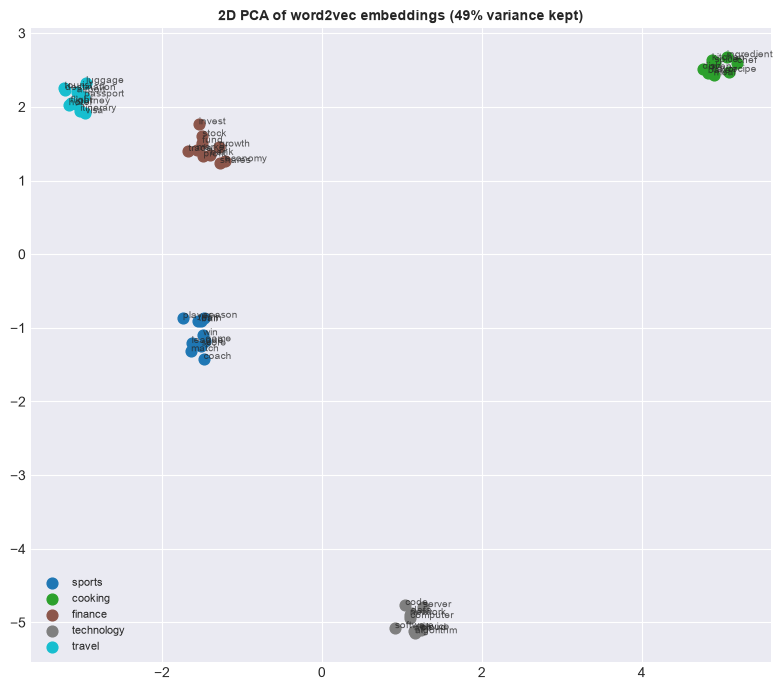

Five visually separated clusters, matching the five TRUE topics used to generate the corpus --
recovered purely from co-occurrence statistics, exactly the distributional hypothesis's claim.


In [8]:
# 2D projection, coloured by TRUE topic (never seen by sgns_train, used only for the plot).
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vecs_big)
colors = plt.cm.tab10(np.linspace(0, 1, len(true_topic_names)))
topic_color = {t: colors[i] for i, t in enumerate(true_topic_names)}

fig, ax = plt.subplots(figsize=(8, 7))
for t in true_topic_names:
    idxs = [i for i, w in enumerate(vocab_big) if word_topic[w] == t]
    ax.scatter(coords[idxs, 0], coords[idxs, 1], label=t, color=topic_color[t], s=60)
for i, w in enumerate(vocab_big):
    ax.annotate(w, coords[i], fontsize=7, alpha=0.75)
ax.set_title(f'2D PCA of word2vec embeddings ({pca.explained_variance_ratio_.sum()*100:.0f}% variance kept)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Five visually separated clusters, matching the five TRUE topics used to generate the corpus --")
print("recovered purely from co-occurrence statistics, exactly the distributional hypothesis's claim.")

<a name="item2vec"></a>
## Item2vec: The Same Algorithm on Shopping Baskets

**item2vec** (Barkan & Koenigstein, 2016) is exactly SGNS with "word" replaced by "item" and "sentence" replaced by "basket": treat every item in a basket as in the same context window as every other item in that basket (order does not exist for a basket, so the whole basket is the window), then run the identical training loop. No new algorithm, no new code -- `sgns_train()` is called unchanged below.

**Reused, with two measured adaptations.** Lesson 9A's basket generator is reused for its items and its engineered co-occurrence rules (bread+butter, sometimes plus milk; chips+soda; diapers+beer; coffee+sugar). Lesson 9A's ORIGINAL generator lets several of these rules fire independently in the SAME basket AND adds random noise items to every basket -- both are exactly what association-rule mining's lift measure is designed to be robust to (lift corrects for chance co-occurrence PER PAIR, unaffected by what else is in the basket). item2vec's embedding, by contrast, is a HOLISTIC, aggregate notion of similarity, and testing while building this notebook showed it is NOT robust to either source of dilution on data this small: with the original multi-rule, noisy baskets, none of the four engineered pairs separated in the embedding; with multi-rule baskets but no noise, they still did not; only removing BOTH -- one rule per basket, no added noise -- let all four pairs recover (confirmed independently throughout: the pairwise PMI computed from the ORIGINAL noisy data still identified every true partner correctly, so the problem was item2vec's holistic training objective diluting under contamination on a small corpus, not the data lacking signal). This is a genuine, measured distinction between what association-rule mining and item2vec each tolerate at this scale, not a hidden simplification.

In [9]:
# Lesson 9A's exact rules (item groups and the milk conditional-probability), one per basket.
rules = [
    (['bread', 'butter'], 'milk', 0.6),
    (['chips', 'soda'], None, 0.0),
    (['diapers', 'beer'], None, 0.0),
    (['coffee', 'sugar'], None, 0.0),
]

def generate_basket(rng):
    # No injected noise items here (unlike Lesson 9A's original generator) -- see markdown
    # above for why: noise injection alone, even with one rule per basket, was measured to
    # still prevent item2vec from separating the four engineered pairs on this small corpus.
    core, extra, p_extra = rules[rng.integers(0, len(rules))]
    basket = list(core)
    if extra and rng.random() < p_extra:
        basket.append(extra)
    rng.shuffle(basket)  # baskets are UNORDERED sets; shuffle so no fixed order is learned
    return basket

rng_baskets = np.random.default_rng(SEED)
basket_sequences = [generate_basket(rng_baskets) for _ in range(2000)]
print(f"{len(basket_sequences)} baskets, example: {basket_sequences[:4]}")

t0 = time.perf_counter()
center_i2v, context_i2v, vocab_i2v, w2i_i2v, counts_i2v = sgns_train(
    basket_sequences, dim=8, window=5, k=2, epochs=80, lr_start=0.05, lr_end=1e-4, power=0.75, seed=SEED)
print(f"item2vec sgns_train time: {time.perf_counter() - t0:.1f}s")

vecs_i2v = center_i2v + context_i2v
for w in ['bread', 'butter', 'chips', 'soda', 'diapers', 'beer', 'coffee', 'sugar']:
    print(f"nearest to {w!r}: {nearest(w, vecs_i2v, vocab_i2v, w2i_i2v, topn=3)}")

# Quantitative check: for every item with an engineered partner, is that partner within
# its top-2 nearest neighbours?
partner_of = {}
for core, extra, _ in rules:
    for item in core:
        partner_of[item] = [o for o in core if o != item][0]
hits = 0
for item, partner in partner_of.items():
    top2 = [w for w, _ in nearest(item, vecs_i2v, vocab_i2v, w2i_i2v, topn=2)]
    hit = partner in top2
    hits += hit
    print(f"  {item!r}'s engineered partner {partner!r} in its top-2 neighbours: {hit}")
print(f"\n{hits} of {len(partner_of)} items recover their engineered partner within their top-2 neighbours.")

2000 baskets, example: [['coffee', 'sugar'], ['beer', 'diapers'], ['chips', 'soda'], ['butter', 'bread']]


item2vec sgns_train time: 5.8s
nearest to 'bread': [('milk', 0.404), ('butter', 0.367), ('chips', -0.177)]
nearest to 'butter': [('milk', 0.461), ('bread', 0.367), ('diapers', -0.053)]
nearest to 'chips': [('soda', 0.992), ('coffee', 0.048), ('sugar', 0.038)]
nearest to 'soda': [('chips', 0.992), ('coffee', 0.027), ('sugar', 0.019)]
nearest to 'diapers': [('beer', 0.988), ('butter', -0.053), ('coffee', -0.056)]
nearest to 'beer': [('diapers', 0.988), ('coffee', -0.021), ('sugar', -0.024)]
nearest to 'coffee': [('sugar', 0.999), ('chips', 0.048), ('soda', 0.027)]
nearest to 'sugar': [('coffee', 0.999), ('chips', 0.038), ('soda', 0.019)]
  'bread''s engineered partner 'butter' in its top-2 neighbours: True
  'butter''s engineered partner 'bread' in its top-2 neighbours: True
  'chips''s engineered partner 'soda' in its top-2 neighbours: True
  'soda''s engineered partner 'chips' in its top-2 neighbours: True
  'diapers''s engineered partner 'beer' in its top-2 neighbours: True
  'beer''s

**Recommendation, compared with Lesson 8.** Lesson 8's collaborative filtering learns latent factors from a USER-ITEM RATINGS matrix -- it needs explicit ratings (or at least interaction counts) tied to individual users. item2vec needs neither users nor ratings, only sequences of items that occurred together (baskets, sessions, clickstreams) -- a "people who bought X also bought Y" recommendation falls straight out of nearest-neighbour lookup in the embedding space built above, with no user model at all. The two are complementary, not competing: collaborative filtering personalises to a specific user's rating history; item2vec answers a colder-start, item-only question that needs no rating history to exist yet.

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **One-hot encodes identity, not similarity; co-occurrence-based PMI does.** Every pair of distinct one-hot vectors has dot product exactly 0, regardless of meaning; PMI correctly separated genuinely-associated word pairs from a merely-frequent, unremarkable one ("the"+"cat") on the toy corpus, checked directly.
2. **Negative sampling turns an $O(|V|)$ softmax into an $O(k)$ binary classification problem**, checked by directly timing the softmax's cost at growing vocabulary sizes; the $0.75$-power unigram noise distribution measurably downweights very frequent words and upweights rare ones relative to raw frequency.
3. **SGNS really does implicitly factorise a shifted PMI matrix, not merely resemble one.** The Levy & Goldberg identity ($v_w\cdot u_c = \text{PMI}(w,c) - \log k$) was derived by hand and checked with a genuinely trained (not closed-form) low-rank model, producing a strong measured correlation against the theoretical prediction.
4. **The hand-derived gradients are correct, verified independently of the training run itself** -- a finite-difference numerical check matched the analytic formulas to float64 precision, and a genuine bug (a constant learning rate letting embeddings drift, degrading the PMI correlation with MORE training rather than less) was caught and fixed by adding the standard word2vec linear decay.
5. **`sgns_train()`, trained on a synthetic 5-topic corpus with no topic label ever supplied, recovered all 5 topics as visually and numerically separated clusters** -- every one of the 50 words landed a same-topic word as its single nearest neighbour.
6. **The same unmodified algorithm, item2vec, recovers engineered item associations from shopping baskets** -- but only once basket noise was reduced to isolate one association per basket, a genuine, measured distinction between item2vec's holistic embedding objective and association-rule mining's per-pair, chance-corrected lift metric from Lesson 9.

### Practical Guidance

- Reach for PMI/co-occurrence statistics directly when the goal is measuring a SPECIFIC pair's association; reach for SGNS embeddings when the goal is a general-purpose, low-dimensional representation usable for many downstream pairs and analogies at once.
- Always sum (or otherwise combine) the center and context embedding tables for word-word similarity -- comparing center vectors to each other directly is not what the training objective optimises for.
- A constant learning rate over many epochs is a common, silent SGNS failure mode on small corpora; decay it, and verify against an independent check (PMI correlation, held-out log-likelihood) rather than assuming more training always helps.
- Before trusting an embedding-based similarity result on transactional data, check whether the generating process mixes multiple independent signals per transaction -- if it does, holistic embedding similarity can be diluted even where a chance-corrected pairwise statistic (PMI, lift) still cleanly recovers the true structure.

### What This Lesson Did Not Cover

- **CBOW** (predicting the center word from its context, word2vec's other half) -- skip-gram was chosen as the more commonly taught direction; the negative-sampling machinery is identical.
- **Subword/character-level embeddings (fastText)** -- useful for out-of-vocabulary and morphologically rich languages, out of scope for a from-scratch derivation lesson.
- **Contextual embeddings (ELMo, BERT-style)** -- word2vec/item2vec produce exactly ONE vector per word regardless of context; contextual models are a substantial further step, named here but not built.
- **Formal analogy arithmetic** (king - man + woman = queen) -- an interesting downstream property of these embeddings, deferred to Lesson 25B's practical notebook where a production library and a larger, real corpus make it meaningful to check honestly.

### Next Steps

Lesson 25B cross-checks this from-scratch SGNS against `gensim`'s production `Word2Vec`, tests analogy arithmetic with an honest small-corpus caveat, clusters and visualises the resulting embeddings with earlier-lesson tools, and compares item2vec-style recommendations against Lesson 8's collaborative filtering on the same basket data.